## Neural networks(신경망)
- 퍼셉트론 <- 가중치를 수동으로 변경해야함
- 신경망 <- 데이터로 부터 가중치를 업데이트함
---
### 퍼셉트론에서 신경망으로

![Neural network layers](img/neural_network_layers.svg)


퍼셉트론의 활성화 함수를 계단함수 $h()$로 두면 출력은 다음과 같이 표현할 수 있습니다.

$$
a = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

$$
y = h(a)
$$

$$
h(a) =
\begin{cases}
0 & (a \leq 0) \\
1 & (a > 0)
\end{cases}
$$


In [8]:
import numpy as np
import matplotlib.pylab as plt

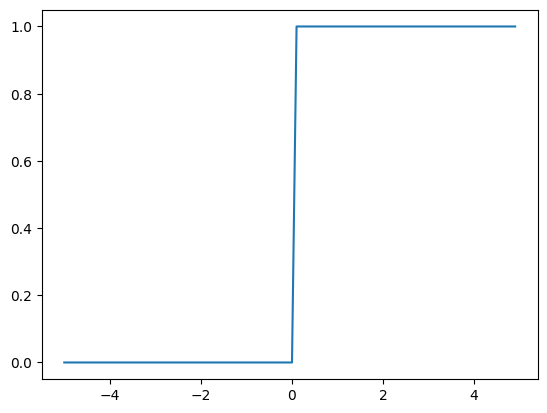

In [19]:
# Simple Step_function
def step_function(x):
    # TRUE = 1 or FALSE = 0
    return np.array(x > 0, dtype=int)


x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)

plt.plot(x, y)
plt.show()

### Sigmoid Function Example

신경망에서 자주 사용하는 시그모이드 함수의 예시는 다음과 같습니다.

$$
h(x) = \frac{1}{1 + e^{-x}}
$$


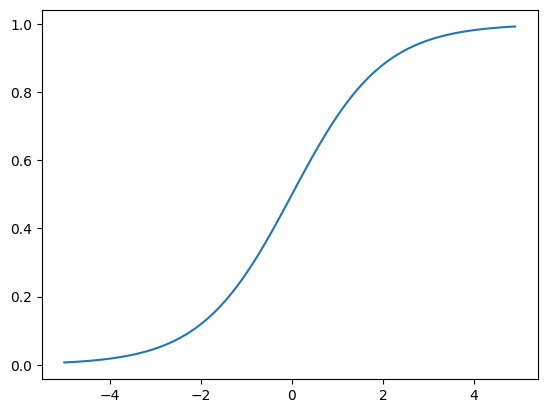

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.show()

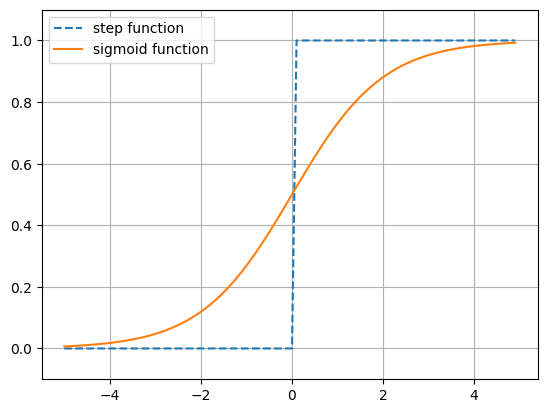

In [21]:
x = np.arange(-5.0, 5.0, 0.1)
y_step = step_function(x)
y_sigmoid = sigmoid(x)

plt.plot(x, y_step, linestyle='--', label='step function')
plt.plot(x, y_sigmoid, label='sigmoid function')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

## 비선형 함수
#### 계단 함수와 시그모이드 함수의 공통점
- 0 ~ 1 사이의 값을 가진다
- 비선형 함수(직선-선형이 아닌 함수)
* 선형 함수를 사용해서는 신경망의 층을 깊게하는 의미가 없어진다

## ReLU 함수
- 0을 넘으면 그 입력을 그대로 사용하고, 0 이하라면 0을 출력하는 함수

$$
h(x) =
\begin{cases}
0 & (x \leq 0) \\
x & (x > 0)
\end{cases}
$$

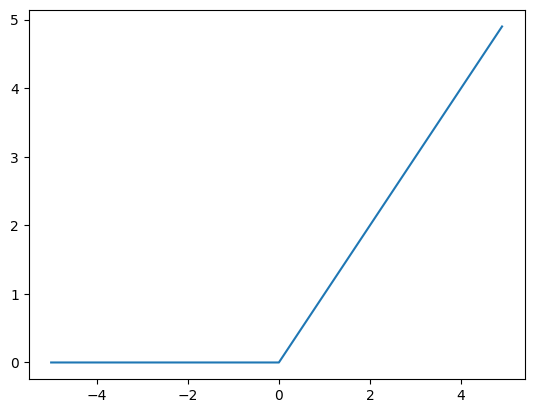

In [22]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.show()

## 활성화 함수 정리

### 빠른 비교

| 함수 | 식 | 장점 | 단점 | 주 사용 위치 |
|---|---|---|---|---|
| Step | $h(x)=\begin{cases}0 & (x \leq 0) \\ 1 & (x > 0)\end{cases}$ | 구조가 단순하고 퍼셉트론 설명에 적합 | 미분이 거의 불가능해서 학습용 신경망에는 부적합 | 퍼셉트론 개념 설명 |
| Sigmoid | $h(x)=\frac{1}{1+e^{-x}}$ | 출력이 0~1이라 확률 해석이 쉬움 | 기울기 소실 문제 발생 가능 | 출력층, 초기 신경망 |
| ReLU | $h(x)=\max(0,x)$ | 계산이 빠르고 학습이 잘 됨 | 음수 구간에서 뉴런이 죽을 수 있음 | 은닉층 |

### 함수별 핵심 정리

#### 1. Step Function
- 핵심: 입력이 기준을 넘으면 1, 아니면 0을 출력한다.
- 장점: 이진 분류 원리를 설명하기 쉽다.
- 단점: 미분이 어려워 역전파 학습에 쓰기 힘들다.

#### 2. Sigmoid Function
- 핵심: 출력값이 0과 1 사이로 부드럽게 변한다.
- 장점: 확률처럼 해석하기 좋다.
- 단점: 입력 절댓값이 커지면 기울기가 매우 작아진다.
- 자주 쓰는 곳: 이진 분류의 출력층

#### 3. ReLU Function
- 핵심: 0보다 크면 그대로 출력하고, 아니면 0을 출력한다.
- 장점: 계산이 단순하고 학습 속도가 빠르다.
- 단점: 음수 구간에서는 기울기가 0이라 dying ReLU 문제가 생길 수 있다.
- 자주 쓰는 곳: 대부분의 은닉층

### 은닉층에서 자주 쓰는 추가 함수

- tanh: $h(x)=\tanh(x)$
  출력 범위가 -1에서 1이라 시그모이드보다 중심이 0에 가깝다.

- Leaky ReLU: $h(x)=\max(ax,x)$
  음수 구간에도 작은 기울기를 남겨 dying ReLU 문제를 완화한다.

- ELU
  음수 구간 정보를 일부 유지하도록 설계된 함수이다.

- GELU
  Transformer 계열 모델에서 자주 사용되며, 입력을 부드럽게 통과시킨다.

- Swish: $h(x)=x\cdot\sigma(x)$
  ReLU보다 부드러운 비선형성을 제공한다.

### 현재 기준으로 보면
- 은닉층: 보통 ReLU 또는 ReLU 계열 함수 사용
- 이진 분류 출력층: sigmoid 사용
- 다중 분류 출력층: softmax 사용
- 회귀 출력층: 선형 함수 사용


## 신경망의 순방향 행렬연산

![Neural network matrix operation](img/neural_network_matrix_ops.svg)

신경망에서는 각 뉴런을 하나씩 계산하기보다, 입력과 가중치를 행렬 형태로 묶어서 한 번에 계산한다.

입력 벡터를 $\mathbf{x}$, 가중치 행렬을 $W$, 편향 벡터를 $\mathbf{b}$라고 하면 선형 결합은 다음과 같다.

$$
\mathbf{a} = W\mathbf{x} + \mathbf{b}
$$

그 다음 활성화 함수를 적용해서 출력 벡터를 만든다.

$$
\mathbf{z} = h(\mathbf{a})
$$

예를 들어 입력이 3개이고 다음 층의 뉴런이 3개라면,
- $\mathbf{x}$의 크기: $(3 \times 1)$
- $W$의 크기: $(3 \times 3)$
- $\mathbf{b}$의 크기: $(3 \times 1)$
- 결과 $\mathbf{a}, \mathbf{z}$의 크기: $(3 \times 1)$

이 방식의 장점은 모든 뉴런의 계산을 한 번에 처리할 수 있어서 코드가 간결해지고, 넘파이 같은 라이브러리로 빠르게 계산할 수 있다는 점이다.


## 출력층과 머신러닝 문제 유형

머신러닝의 문제는 크게 **분류(classification)** 와 **회귀(regression)** 로 나눌 수 있다. 출력층은 이 문제 유형에 맞게 다르게 설계한다.

### 1. 분류 문제
분류는 입력이 어떤 **범주에 속하는지** 맞히는 문제이다.

- 예시 1: 이메일이 스팸인지 아닌지 판별
- 예시 2: 손글씨 이미지가 0~9 중 어떤 숫자인지 판별
- 예시 3: 사진이 고양이인지 개인지 판별

분류 문제에서는 출력값을 보통 확률처럼 해석하고 싶기 때문에, 출력층에서 값을 일정한 범위로 바꾸는 함수를 사용한다.

- **이진 분류**: 보통 `sigmoid` 함수를 사용한다.
- 이유: 출력값이 0과 1 사이가 되어, 어떤 클래스일 확률처럼 해석하기 쉽다.

$$
h(a) = \frac{1}{1 + e^{-a}}
$$

- **다중 분류**: 보통 `softmax` 함수를 사용한다.
- 이유: 여러 클래스의 출력값을 전체 합이 1이 되도록 바꾸어, 각 클래스에 대한 확률 분포로 해석할 수 있다.

$$
y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}}
$$

### 2. 회귀 문제
회귀는 입력에 대해 **연속적인 수치값** 을 예측하는 문제이다.

- 예시 1: 집 가격 예측
- 예시 2: 내일의 기온 예측
- 예시 3: 월별 판매량 예측

회귀 문제에서는 출력값 자체가 예측해야 할 실제 숫자이므로, 출력층에서 값을 억지로 0과 1 사이로 제한하지 않는 것이 보통 더 자연스럽다.

- **회귀 문제의 출력층**: 보통 `identity function` 또는 `linear function`을 사용한다.
- 이유: 예측값을 그대로 출력해야 하므로 출력 범위를 제한하지 않는 편이 적합하다.

$$
h(a) = a
$$

### 정리

| 문제 유형 | 대표 예시 | 출력층 함수 | 사용하는 이유 |
|---|---|---|---|
| 이진 분류 | 스팸 메일 판별, 고양이/개 분류 | sigmoid | 출력이 0~1 범위라 확률처럼 해석하기 쉽다 |
| 다중 분류 | 숫자 0~9 판별, 품종 분류 | softmax | 여러 클래스의 확률 합을 1로 만들 수 있다 |
| 회귀 | 집값, 기온, 판매량 예측 | identity / linear | 연속적인 실수값을 그대로 출력할 수 있다 |




## 소프트맥스 함수의 변형과 오버플로 개선

소프트맥스 함수는 다중 분류에서 출력층에 자주 사용하며, 기본 형태는 다음과 같다.

$$
y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}}
$$

그런데 입력값 `a` 에 매우 큰 수가 들어오면 `e^{a_k}` 가 너무 커져서 **overflow** 가 발생할 수 있다. 예를 들어 `a = [1010, 1000, 990]` 같은 값에서는 `np.exp(a)` 계산이 불안정해질 수 있다.

소프트맥스는 모든 입력에 같은 상수 `C` 를 더하거나 빼도 결과가 변하지 않는다.

$$
y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}} = \frac{e^{a_k - C}}{\sum_{i=1}^{n} e^{a_i - C}}
$$

따라서 보통 `C = \max(a)` 를 사용해서 가장 큰 값을 0으로 맞춘 뒤 계산한다. 그러면 지수값이 지나치게 커지는 것을 막을 수 있어 수치적으로 더 안정적이다.


### 소프트맥스 함수의 특징

- 출력값이 모두 0과 1 사이의 값이 된다.
- 모든 출력값의 합이 1이 되므로 확률 분포처럼 해석할 수 있다.
- 입력값이 가장 큰 원소가 가장 큰 출력값으로 변환된다.
- 여러 클래스 중 하나를 고르는 **다중 분류 문제의 출력층** 에 자주 사용된다.
- 입력값 차이를 지수 함수로 반영하므로, 큰 값은 더 크게 강조되고 작은 값은 더 작아진다.
- 큰 입력값에서는 지수 계산 때문에 overflow 문제가 생길 수 있어, 실제 구현에서는 보통 최댓값을 빼서 계산한다.
- 학습 단계에서는 소프트맥스 함수를 사용하지만, 추론 단계에서는 소프트맥스 함수를 생략해도 된다.(비용 + 출력이 가장 큰 뉴런의 위치는 달라지지 않음)

In [ ]:
# stable softmax
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

## MNIST 데이터셋을 활용한 간단한 숫자 분류기

이번 목표는 **학습은 하지 않고**, MNIST 데이터셋과 **이미 학습된 매개변수**를 이용해 숫자 이미지를 분류하는 **순전파(forward propagation)** 만 구현하는 것이다.

- 데이터셋: 손글씨 숫자 이미지 0~9
- 입력: 28 x 28 흑백 이미지
- 출력: 10개 숫자 클래스에 대한 점수와 예측값
- 학습 방식: 직접 학습하지 않고, 미리 학습된 가중치를 불러와 추론만 수행


### MNIST 데이터셋 설명

MNIST는 머신러닝과 딥러닝 입문에서 가장 자주 쓰이는 손글씨 숫자 데이터셋이다. 각 이미지는 **28 x 28 픽셀의 흑백 이미지**이며, 정답 레이블은 **0부터 9까지의 숫자**이다.

- 학습 데이터: 60,000장
- 테스트 데이터: 10,000장
- 한 장의 이미지를 펼치면 784차원 벡터가 된다.
- 분류 문제의 대표 예시로 자주 사용된다.

![MNIST overview](img/mnist_dataset_overview.svg)


In [2]:
import subprocess
from pathlib import Path

repo_dir = Path("deep-learning-from-scratch")

if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/oreilly-japan/deep-learning-from-scratch.git"],
        check=True,
    )
else:
    print(f"already exists: {repo_dir.resolve()}")

already exists: /Users/pppp/Desktop/DeepLearning/chp_03_neural_net/deep-learning-from-scratch


In [3]:
import sys
from pathlib import Path

import numpy as np

repo_dir = Path("deep-learning-from-scratch")
if str(repo_dir.resolve()) not in sys.path:
    sys.path.append(str(repo_dir.resolve()))

from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(
    normalize=True,
    flatten=True,
    one_hot_label=False,
)

print("x_train shape:", x_train.shape)
print("t_train shape:", t_train.shape)
print("x_test shape:", x_test.shape)
print("t_test shape:", t_test.shape)
print("pixel range:", x_train.min(), "~", x_train.max())

Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
x_train shape: (60000, 784)
t_train shape: (60000,)
x_test shape: (10000, 784)
t_test shape: (10000,)
pixel range: 0.0 ~ 1.0


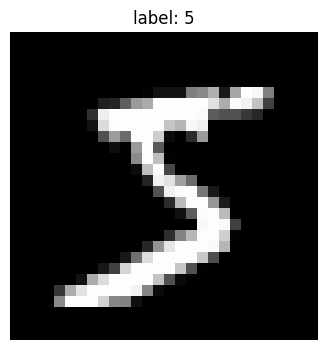

In [41]:
import matplotlib.pyplot as plt

index = 0
img = x_train[index].reshape(28, 28)
label = t_train[index]

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

### 이미 학습된 매개변수를 이용한 순전파 추론

MNIST 이미지를 확인한 뒤에는, 저장소에 포함된 `sample_weight.pkl` 파일을 불러와 순전파만 수행할 수 있다. 여기서는 `load_mnist(normalize=True)`로 데이터를 로드했기 때문에, 입력 이미지가 이미 **0~1 범위로 정규화된 상태**이며 그대로 추론에 사용할 수 있다.


In [42]:
import pickle


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def init_network():
    weight_path = repo_dir / "ch03" / "sample_weight.pkl"
    with open(weight_path, "rb") as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    W1, W2, W3 = network["W1"], network["W2"], network["W3"]
    b1, b2, b3 = network["b1"], network["b2"], network["b3"]

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y


network = init_network()

x_for_inference = x_test
sample_index = 1
y = predict(network, x_for_inference[sample_index])
pred = np.argmax(y)

print("predicted:", pred)
print("answer:", t_test[sample_index])
print("probabilities:", y)

predicted: 2
answer: 2
probabilities: [4.83633205e-03 1.10458618e-03 9.44252193e-01 1.43091455e-02
 5.69895803e-07 6.67604432e-03 2.75333542e-02 1.27084400e-06
 1.28642365e-03 4.78646847e-08]


C:\Users\P\AppData\Local\Temp\ipykernel_40840\3290762583.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


### 정확도 측정

테스트 데이터 전체를 하나씩 순전파에 넣고, 예측값과 정답이 일치하는 비율을 계산하면 분류기의 정확도를 확인할 수 있다.


In [43]:
accuracy_count = 0

for i in range(len(x_for_inference)):
    y = predict(network, x_for_inference[i])
    p = np.argmax(y)
    if p == t_test[i]:
        accuracy_count += 1

accuracy = accuracy_count / len(x_for_inference)
print("Accuracy:", accuracy)

Accuracy: 0.9352


### 배치 처리

앞의 코드는 테스트 데이터를 **한 장씩** 꺼내어 순전파를 수행했다. 하지만 여러 장의 이미지를 한 번에 묶어서 계산하면 더 효율적으로 추론할 수 있는데, 이를 **배치 처리(batch processing)** 라고 한다.

예를 들어 배치 크기를 100으로 두면 입력 `x_batch` 의 shape는 `(100, 784)` 가 된다. 이때 각 층의 행렬 연산은 다음처럼 표현할 수 있다.

- `x_batch`: `(100, 784)`
- `W1`: `(784, 50)`, `b1`: `(50,)`
- `a1 = np.dot(x_batch, W1) + b1`: `(100, 50)`
- `z1 = sigmoid(a1)`: `(100, 50)`
- `a2 = np.dot(z1, W2) + b2`: `(100, 100)`
- `z2 = sigmoid(a2)`: `(100, 100)`
- `a3 = np.dot(z2, W3) + b3`: `(100, 10)`
- `y = softmax(a3)`: `(100, 10)`

즉, 이미지 100장을 하나씩 계산하는 대신 **행렬 한 번의 곱셈으로 동시에 처리**하므로 속도가 좋아진다. 마지막에는 `axis=1` 기준으로 `argmax` 를 적용해 각 이미지의 예측 숫자를 구한다.


In [44]:
batch_size = 100
accuracy_count = 0

for i in range(0, len(x_for_inference), batch_size):
    x_batch = x_for_inference[i:i + batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_count += np.sum(p == t_test[i:i + batch_size])

batch_accuracy = accuracy_count / len(x_for_inference)
print("Batch Accuracy:", batch_accuracy)
print("x_batch shape:", x_for_inference[:batch_size].shape)
print("y_batch shape:", predict(network, x_for_inference[:batch_size]).shape)

Batch Accuracy: 0.9352
x_batch shape: (100, 784)
y_batch shape: (100, 10)


### 배치 처리의 장단점

**장점**

- 여러 데이터를 한 번에 행렬 연산으로 처리하므로 계산 속도가 빠르다.
- NumPy, GPU 같은 병렬 연산 자원을 더 효율적으로 활용할 수 있다.
- 코드가 벡터화되어 반복문을 줄일 수 있고, 대량 데이터 처리에 유리하다.

**단점**

- 한 번에 여러 데이터를 메모리에 올려야 하므로 메모리 사용량이 커진다.
- 배치 크기가 너무 크면 오히려 메모리 부족이나 속도 저하가 생길 수 있다.
- 실시간으로 데이터 한 개씩 바로 처리해야 하는 상황에서는 작은 배치나 단일 처리보다 지연이 생길 수 있다.
- 입력 shape를 배치 기준으로 맞춰야 하므로 처음에는 코드 구조가 조금 더 복잡해질 수 있다.

즉, 배치 처리는 **대량 데이터를 빠르게 처리할 때 매우 유리**하지만, 메모리와 지연 시간도 함께 고려해서 적절한 배치 크기를 정해야 한다.
